In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
df = pd.read_csv("supermarket_sales.csv")

In [6]:
df.head()

,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [7]:
df.shape

(1000, 17)

In [8]:
df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender_customer',
       'product_line', 'unit_cost', 'quantity', '5pct_markup', 'revenue',
       'date', 'time', 'payment_method', 'cogs', 'gm_pct', 'gross_income',
       'rating'],
      dtype='object')

In [10]:
df.dtypes

,0
invoice_id,object
branch,object
city,object
customer_type,object
gender_customer,object
product_line,object
unit_cost,float64
quantity,int64
5pct_markup,float64
revenue,float64


In [11]:
df.describe()

,unit_cost,quantity,5pct_markup,revenue,cogs,gm_pct,gross_income,rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [12]:
df.isna().sum()

,0
invoice_id,0
branch,0
city,0
customer_type,0
gender_customer,0
product_line,0
unit_cost,0
quantity,0
5pct_markup,0
revenue,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Branch'].value_counts()

KeyError: 'Branch'

In [15]:
df['branch'].value_counts()

,count
branch,
A,340
B,332
C,328


In [16]:
df['city'].value_counts()

,count
city,
Yangon,340
Mandalay,332
Naypyitaw,328


In [17]:
df['product_line'].value_counts()

,count
product_line,
Fashion accessories,178
Food and beverages,174
Electronic accessories,170
Sports and travel,166
Home and lifestyle,160
Health and beauty,152


In [18]:
df['total'].mean()

KeyError: 'total'

In [19]:
df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender_customer',
       'product_line', 'unit_cost', 'quantity', '5pct_markup', 'revenue',
       'date', 'time', 'payment_method', 'cogs', 'gm_pct', 'gross_income',
       'rating'],
      dtype='object')

In [20]:
df['revenue'].mean()

np.float64(322.966749)

In [21]:
df['revenue'].min()

10.6785

In [22]:
df['revenue'].max()

1042.65

In [23]:
df.groupby('city')['revenue'].mean()

,revenue
city,
Mandalay,319.872506
Naypyitaw,337.099715
Yangon,312.354031


In [24]:
df.groupby('product_line')['revenue'].sum()

,revenue
product_line,
Electronic accessories,54337.5315
Fashion accessories,54305.8950
Food and beverages,56144.8440
Health and beauty,49193.7390
Home and lifestyle,53861.9130
Sports and travel,55122.8265


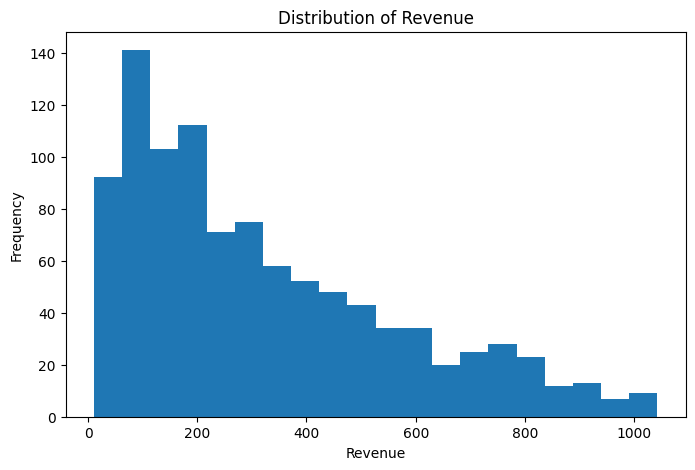

In [33]:
plt.figure(figsize=(8,5))
plt.hist(df['revenue'], bins=20)
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

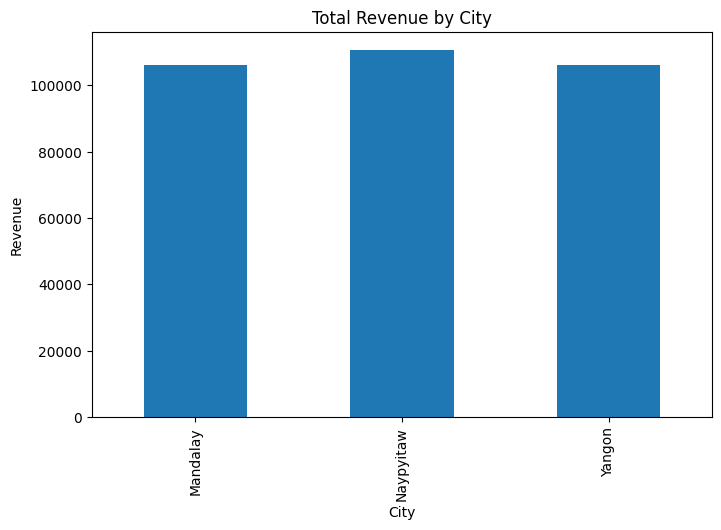

In [35]:
city_sales = df.groupby('city')['revenue'].sum()

plt.figure(figsize=(8,5))
city_sales.plot(kind='bar')
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

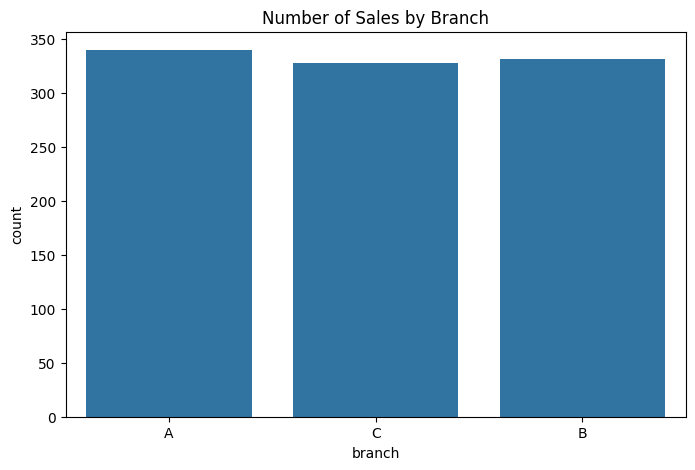

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(x='branch', data=df)
plt.title('Number of Sales by Branch')
plt.show()

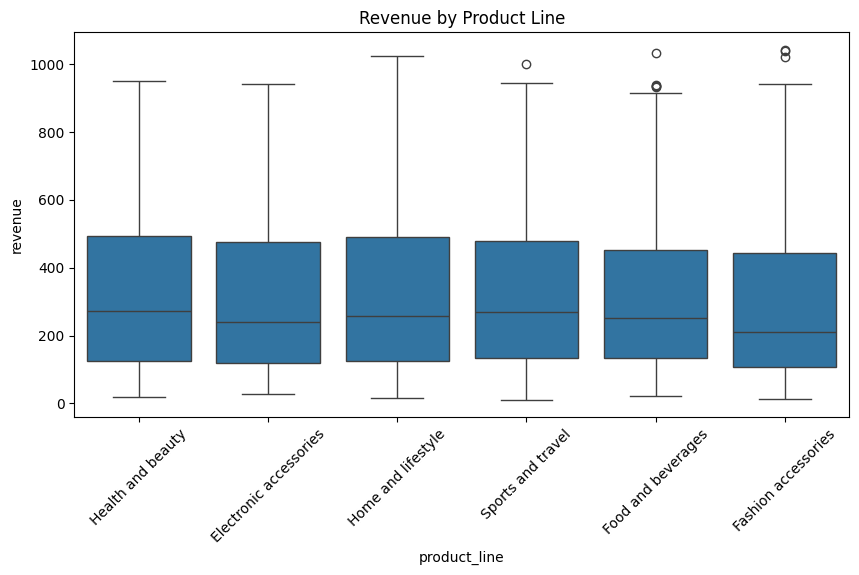

In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(x='product_line', y='revenue', data=df)
plt.xticks(rotation=45)
plt.title('Revenue by Product Line')
plt.show()

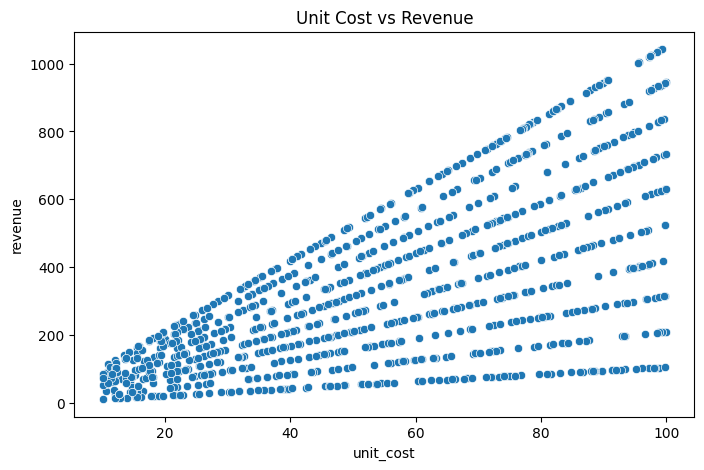

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='unit_cost', y='revenue', data=df)
plt.title('Unit Cost vs Revenue')
plt.show()

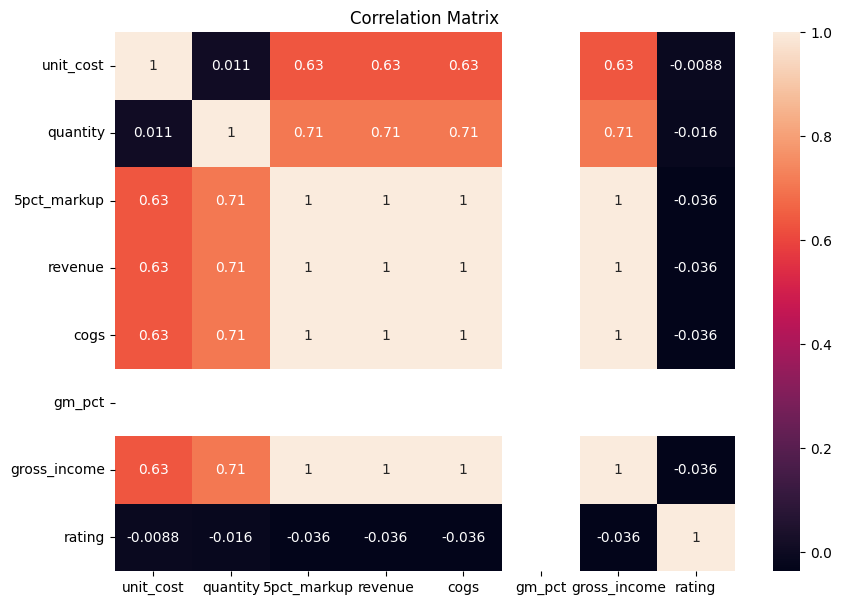

In [39]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

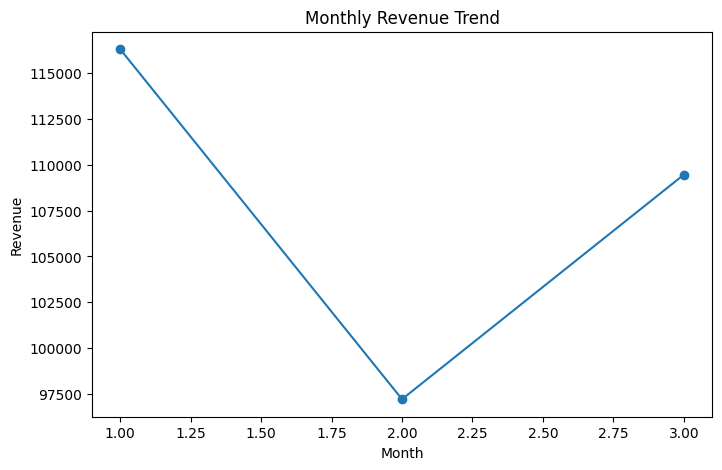

In [40]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

monthly_sales = df.groupby('month')['revenue'].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

Conclusion:
The Supermarket Sales dataset was explored using Pandas, Matplotlib, and Seaborn.
The analysis included descriptive statistics, missing values, duplicates,
grouping, sales distributions, relationships between variables, and correlation analysis.